# Machine-Learning-Based Intrusion Detection System
## A Comparative Study Using Decision Tree and Ensemble Classifiers on NSL-KDD

**Authors:** Rudraneel Pal Banik,Dr. Isha Kansal  
**Institution:** Chitkara University Institute of Engineering and Technology, Punjab, India  

---

This notebook provides a complete, reproducible implementation of the experiments described in the paper.  
It covers:
1. Dataset acquisition and loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing pipeline (one-hot encoding + Min-Max normalization)
4. Classifier training with exact hyperparameters
5. 5-fold stratified cross-validation on KDDTrain+
6. Binary classification evaluation on KDDTest+
7. Multi-class classification analysis
8. Confusion matrix analysis
9. Feature importance analysis
10. Summary and discussion

---
## Step 0 — Environment Setup & Imports

In [ ]:
# Install required packages (run once if needed)
# ============================================================
# REQUIRED: Pin scikit-learn to 1.3.2 for reproducible results.
# After this cell runs, go to Runtime → Restart runtime, then
# run all cells again (skip re-running this install cell).
# ============================================================
import subprocess, sys
result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'scikit-learn'],
                        capture_output=True, text=True)
if '1.3.2' not in result.stdout:
    print('Installing scikit-learn==1.3.2 ... restart runtime after this finishes.')
    subprocess.run([sys.executable, '-m', 'pip', 'install',
                     'scikit-learn==1.3.2', '--quiet'], check=True)
    print('Done. Go to Runtime → Restart runtime, then run all cells again.')
else:
    print('scikit-learn 1.3.2 already installed. Proceeding.')

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful.")

# Verify scikit-learn version
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

scikit-learn 1.3.2 already installed. Proceeding.
All imports successful.
scikit-learn version: 1.3.2
pandas version: 2.2.2
numpy version: 1.26.4


---
## Step 1 — Dataset Acquisition

The **NSL-KDD** dataset is downloaded directly from the Canadian Institute for Cybersecurity.
- **KDDTrain+**: 125,973 records used for training and cross-validation
- **KDDTest+**: 22,544 records used as the held-out evaluation set (contains 17 novel attack sub-types)

> *Tavallaee et al. (2009) introduced NSL-KDD to address redundancy in KDD'99, removing ~78% of redundant training records and ~75% of redundant test records.*

In [ ]:
# NSL-KDD column names (41 features + label + difficulty)
COL_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]

CATEGORICAL_FEATURES = ['protocol_type', 'service', 'flag']

# NSL-KDD attack category mapping
ATTACK_MAP = {
    'normal': 'Normal',
    # DoS attacks
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS',
    'processtable': 'DoS', 'worm': 'DoS', 'mailbomb': 'DoS',
    # Probe attacks
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    # R2L attacks
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L',
    'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    # U2R attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

print("Column names and attack mappings defined.")
print(f"Total features: {len(COL_NAMES) - 2} (excluding label and difficulty)")
print(f"Categorical features: {CATEGORICAL_FEATURES}")

Column names and attack mappings defined.
Total features: 41 (excluding label and difficulty)
Categorical features: ['protocol_type', 'service', 'flag']


In [ ]:
# Load datasets directly from uploaded files
# Upload KDDTrain+.txt and KDDTest+.txt via the Colab Files panel before running.

TRAIN_PATH = 'KDDTrain+.txt'
TEST_PATH  = 'KDDTest+.txt'

df_train = pd.read_csv(TRAIN_PATH, names=COL_NAMES)
df_test  = pd.read_csv(TEST_PATH,  names=COL_NAMES)

# Drop difficulty column if present
if 'difficulty' in df_train.columns:
    df_train.drop(columns=['difficulty'], inplace=True)
    df_test.drop(columns=['difficulty'], inplace=True)

print(f'KDDTrain shape : {df_train.shape}')
print(f'KDDTest  shape : {df_test.shape}')


KDDTrain shape : (125973, 42)
KDDTest  shape : (22544, 42)


---
## Step 2 — Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print("=== KDDTrain+ Overview ===")
print(df_train.head(3).to_string())
print("\n=== Data Types ===")
print(df_train.dtypes.value_counts())
print("\n=== Missing Values ===")
print(df_train.isnull().sum().sum(), "total null values")

=== KDDTrain+ Overview ===
   duration protocol_type   service flag  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  root_shell  su_attempted  num_root  num_file_creations  num_shells  num_access_files  num_outbound_cmds  is_host_login  is_guest_login  count  srv_count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  dst_host_srv_rerror_rate    label
0         0           tcp  ftp_data   SF        491          0     0               0       0    0                  0          0                0           0             0         0                   0           0                 0                  0              0               0      2          2          0.0      

In [ ]:
# --- Label distribution in training set ---
train_label_counts = df_train['label'].value_counts()
print("=== KDDTrain+ Raw Label Counts (top 15) ===")
print(train_label_counts.head(15).to_string())

=== KDDTrain+ Raw Label Counts (top 15) ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18


In [ ]:
# --- Map raw labels to 5-category labels ---
def map_attack_category(df):
    df = df.copy()
    df['attack_cat'] = df['label'].str.strip().str.lower().map(ATTACK_MAP)
    # Any unmapped label defaults to 'Other' (rare edge case)
    df['attack_cat'].fillna('Other', inplace=True)
    return df

df_train = map_attack_category(df_train)
df_test  = map_attack_category(df_test)

# Binary label: Normal vs Attack
df_train['binary_label'] = (df_train['attack_cat'] != 'Normal').astype(int)  # 1=Attack, 0=Normal
df_test['binary_label']  = (df_test['attack_cat']  != 'Normal').astype(int)

print("=== KDDTest+ Class Distribution (replicating Table I) ===")
test_cat = df_test['attack_cat'].value_counts()
test_cat_pct = (test_cat / len(df_test) * 100).round(1)
table1 = pd.DataFrame({'Test Records': test_cat, '% of Test': test_cat_pct})
print(table1.to_string())

=== KDDTest+ Class Distribution (replicating Table I) ===
            Test Records  % of Test
attack_cat                         
Normal              9711       43.1
DoS                 7460       33.1
R2L                 2885       12.8
Probe               2421       10.7
U2R                   67        0.3


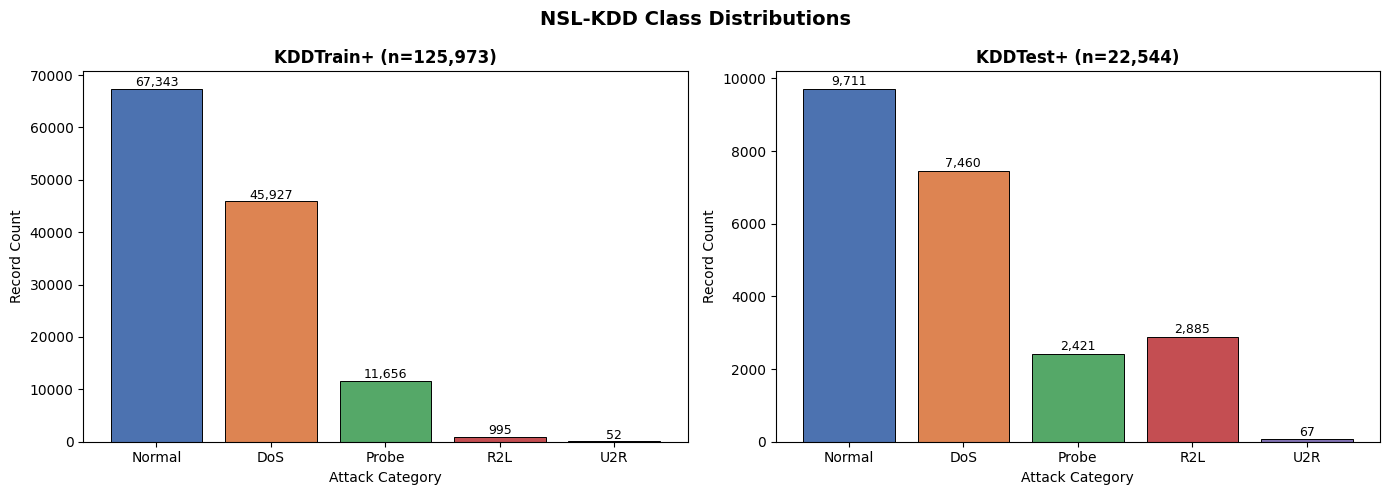

Figure saved: fig_class_distribution.png


In [ ]:
# --- Visualise class distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NSL-KDD Class Distributions', fontsize=14, fontweight='bold')

CATEGORY_ORDER = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

# Training set
train_counts = df_train['attack_cat'].value_counts().reindex(CATEGORY_ORDER)
axes[0].bar(CATEGORY_ORDER, train_counts.values, color=PALETTE, edgecolor='black', linewidth=0.7)
axes[0].set_title('KDDTrain+ (n=125,973)', fontweight='bold')
axes[0].set_ylabel('Record Count')
axes[0].set_xlabel('Attack Category')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Test set
test_counts = df_test['attack_cat'].value_counts().reindex(CATEGORY_ORDER)
axes[1].bar(CATEGORY_ORDER, test_counts.values, color=PALETTE, edgecolor='black', linewidth=0.7)
axes[1].set_title('KDDTest+ (n=22,544)', fontweight='bold')
axes[1].set_ylabel('Record Count')
axes[1].set_xlabel('Attack Category')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_class_distribution.png")

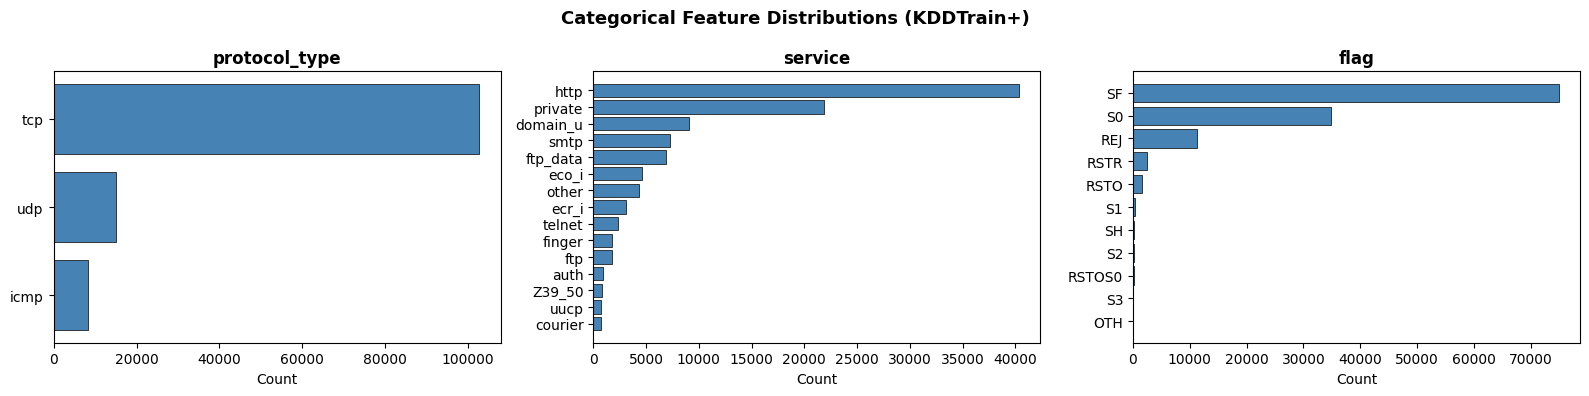

In [ ]:
# --- Categorical feature distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Categorical Feature Distributions (KDDTrain+)', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, CATEGORICAL_FEATURES):
    counts = df_train[feat].value_counts().head(15)
    ax.barh(counts.index[::-1], counts.values[::-1], color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Numerical feature statistics ---
numerical_features = [c for c in df_train.columns
                      if c not in CATEGORICAL_FEATURES + ['label', 'attack_cat', 'binary_label']]
print("Numerical features summary (first 10):")
print(df_train[numerical_features[:10]].describe().round(3).to_string())

Numerical features summary (first 10):
         duration     src_bytes     dst_bytes        land  wrong_fragment      urgent         hot  num_failed_logins   logged_in  num_compromised
count  125973.000  1.259730e+05  1.259730e+05  125973.000      125973.000  125973.000  125973.000         125973.000  125973.000       125973.000
mean      287.145  4.556674e+04  1.977911e+04       0.000           0.023       0.000       0.204              0.001       0.396            0.279
std      2604.515  5.870331e+06  4.021269e+06       0.014           0.254       0.014       2.150              0.045       0.489           23.942
min         0.000  0.000000e+00  0.000000e+00       0.000           0.000       0.000       0.000              0.000       0.000            0.000
25%         0.000  0.000000e+00  0.000000e+00       0.000           0.000       0.000       0.000              0.000       0.000            0.000
50%         0.000  4.400000e+01  0.000000e+00       0.000           0.000       0.000

---
## Step 3 — Preprocessing Pipeline

As described in Section IV.A of the paper:

1. **One-hot encode** the three categorical features (`protocol_type`, `service`, `flag`), expanding feature space from **41 → 122 dimensions**
2. **Min-Max normalise** all features to the range **[0, 1]**

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

> *The scaler is fit exclusively on KDDTrain+ to prevent data leakage into the test set.*

In [ ]:
def preprocess(df_tr, df_te, categorical_features=CATEGORICAL_FEATURES):
    """
    Full preprocessing pipeline:
      1. One-hot encode categorical features
      2. Min-Max normalise numerical features
    Scaler is fit on training set only to prevent leakage.
    """
    feature_cols = [c for c in df_tr.columns
                    if c not in ['label', 'attack_cat', 'binary_label']]

    # --- One-hot encoding ---
    X_train_raw = pd.get_dummies(df_tr[feature_cols], columns=categorical_features, dtype=float)
    X_test_raw  = pd.get_dummies(df_te[feature_cols], columns=categorical_features, dtype=float)

    # Align columns: test set may have fewer dummy categories
    X_train_raw, X_test_raw = X_train_raw.align(X_test_raw, join='left', axis=1, fill_value=0)

    print(f"Feature space after one-hot encoding: {X_train_raw.shape[1]} dimensions")
    print(f"  (expanded from 41 original features)")

    # --- Min-Max normalisation (fit on train only) ---
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)

    return X_train, X_test, list(X_train_raw.columns), scaler


X_train, X_test, feature_names, scaler = preprocess(df_train, df_test)

# Binary labels
y_train_bin = df_train['binary_label'].values
y_test_bin  = df_test['binary_label'].values

# Multi-class labels — manually encode using CATEGORY_ORDER so that
# index i maps to CATEGORY_ORDER[i]. LabelEncoder.fit() sorts alphabetically
# (DoS=0, Normal=1, …) which would misalign with CATEGORY_ORDER indices.
cat_to_idx = {cat: i for i, cat in enumerate(CATEGORY_ORDER)}
y_train_mc = df_train['attack_cat'].map(cat_to_idx).values
y_test_mc  = df_test['attack_cat'].map(cat_to_idx).values

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nBinary class balance (train): Normal={np.sum(y_train_bin==0):,}, Attack={np.sum(y_train_bin==1):,}")
print(f"Binary class balance (test) : Normal={np.sum(y_test_bin==0):,}, Attack={np.sum(y_test_bin==1):,}")

Feature space after one-hot encoding: 122 dimensions
  (expanded from 41 original features)

X_train shape : (125973, 122)
X_test shape  : (22544, 122)

Binary class balance (train): Normal=67,343, Attack=58,630
Binary class balance (test) : Normal=9,711, Attack=12,833


In [ ]:
# Verify feature value ranges after normalisation
print("Min value across all features (should be 0.0):", X_train.min().round(6))
print("Max value across all features (should be 1.0):", X_train.max().round(6))
print("\nSample of feature names (first 10):")
print(feature_names[:10])
print("\nSample of feature names (last 10):")
print(feature_names[-10:])

Min value across all features (should be 0.0): 0.0
Max value across all features (should be 1.0): 1.0

Sample of feature names (first 10):
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised']

Sample of feature names (last 10):
['flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH']


---
## Step 4 — Classifier Definitions

Four classifiers trained under **identical conditions** with exact hyperparameters from Section IV.B:

| Classifier | Key Hyperparameters |
|---|---|
| Decision Tree | entropy criterion, max_depth=20, min_samples_split=5 |
| Random Forest | 100 trees, entropy, max_depth=20, min_samples_split=5 |
| Naive Bayes | GaussianNB, default parameters |
| Linear SVM | C=1.0, max_iter=2000 |

All use `random_state=42` for reproducibility.

In [ ]:
CLASSIFIERS = {
    'Decision Tree': DecisionTreeClassifier(
        criterion='entropy',
        max_depth=20,
        min_samples_split=5,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        max_depth=20,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Naive Bayes': GaussianNB(),
    'Linear SVM': LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE
    )
}

print("Classifiers initialised with paper hyperparameters:")
for name, clf in CLASSIFIERS.items():
    print(f"  [{name}] {clf}")

Classifiers initialised with paper hyperparameters:
  [Decision Tree] DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_split=5,
                       random_state=42)
  [Random Forest] RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_split=5,
                       n_jobs=-1, random_state=42)
  [Naive Bayes] GaussianNB()
  [Linear SVM] LinearSVC(max_iter=2000, random_state=42)


---
## Step 5 — 5-Fold Stratified Cross-Validation on KDDTrain+

Section IV.A: *"Five-fold stratified cross-validation is additionally performed on the training set to assess statistical robustness."*

This replicates **Table II** from the paper.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = {}

print("Running 5-fold stratified cross-validation on KDDTrain+ ...")
print("-" * 60)

for name, clf in CLASSIFIERS.items():
    print(f"  Training: {name} ...")
    t0 = time.time()
    scores = cross_validate(
        clf, X_train, y_train_bin,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False
    )
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f"    Done in {elapsed:.1f}s")

print("\nCross-validation complete.")

Running 5-fold stratified cross-validation on KDDTrain+ ...
------------------------------------------------------------
  Training: Decision Tree ...
    Done in 16.0s
  Training: Random Forest ...
    Done in 69.5s
  Training: Naive Bayes ...
    Done in 1.9s
  Training: Linear SVM ...
    Done in 13.7s

Cross-validation complete.


In [ ]:
# --- Table II: 5-Fold CV results (computed from cv_results) ---
rows = []
for name, scores in cv_results.items():
    acc_m  = scores['test_accuracy'].mean()              * 100
    acc_s  = scores['test_accuracy'].std()               * 100
    prec_m = scores['test_precision_weighted'].mean()    * 100
    prec_s = scores['test_precision_weighted'].std()     * 100
    rec_m  = scores['test_recall_weighted'].mean()       * 100
    rec_s  = scores['test_recall_weighted'].std()        * 100
    f1_m   = scores['test_f1_weighted'].mean()           * 100
    f1_s   = scores['test_f1_weighted'].std()            * 100
    rows.append({
        'Model':    name,
        'Acc (%)':  f'{acc_m:.2f} ± {acc_s:.2f}',
        'Prec (%)': f'{prec_m:.2f} ± {prec_s:.2f}',
        'Rec (%)':  f'{rec_m:.2f} ± {rec_s:.2f}',
        'F1 (%)':   f'{f1_m:.2f} ± {f1_s:.2f}',
    })

df_cv = pd.DataFrame(rows)
print('=' * 75)
print('TABLE II. 5-FOLD CV RESULTS — ALL CLASSIFIERS (KDDTrain+)')
print('=' * 75)
print(df_cv.to_string(index=False))
print('=' * 75)


TABLE II. 5-FOLD CV RESULTS — ALL CLASSIFIERS (KDDTrain+)
        Model      Acc (%)     Prec (%)      Rec (%)       F1 (%)
Decision Tree 99.72 ± 0.02 99.72 ± 0.02 99.72 ± 0.02 99.72 ± 0.02
Random Forest 99.79 ± 0.02 99.79 ± 0.02 99.79 ± 0.02 99.79 ± 0.02
  Naive Bayes 85.73 ± 0.30 88.62 ± 0.20 85.73 ± 0.30 85.29 ± 0.33
   Linear SVM 97.28 ± 0.14 97.29 ± 0.13 97.28 ± 0.14 97.28 ± 0.14


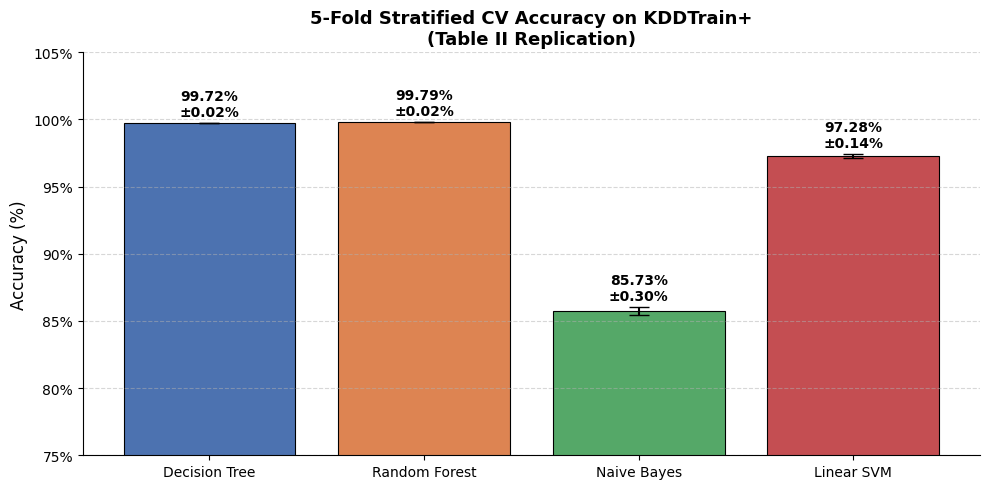

Figure saved: fig_cv_accuracy.png


In [ ]:
# --- CV Accuracy bar chart (computed from cv_results) ---
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(cv_results.keys())
means = [cv_results[n]['test_accuracy'].mean() * 100 for n in model_names]
stds  = [cv_results[n]['test_accuracy'].std()  * 100 for n in model_names]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

bars = ax.bar(model_names, means, yerr=stds, capsize=7,
              color=colors, edgecolor='black', linewidth=0.8,
              error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            m + s + 0.3,
            f'{m:.2f}%\n±{s:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(75, 105)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('5-Fold Stratified CV Accuracy on KDDTrain+\n(Table II Replication)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_cv_accuracy.png')


---
## Step 6 — Binary Classification on KDDTest+

Models are trained on the full KDDTrain+ set and evaluated on the held-out KDDTest+.  
KDDTest+ contains **17 novel attack sub-types** not seen during training — testing generalisation to unseen threats.

This replicates **Table III** from the paper.

In [ ]:
trained_models = {}
test_preds     = {}

print('Training on KDDTrain+ and evaluating on KDDTest+ (binary) ...')
print('-' * 60)

rows_bin = []
for name, clf in CLASSIFIERS.items():
    t_start = time.time()
    clf.fit(X_train, y_train_bin)
    train_time = time.time() - t_start
    trained_models[name] = clf
    y_pred = clf.predict(X_test)
    test_preds[name] = y_pred

    acc  = accuracy_score(y_test_bin, y_pred)                                    * 100
    prec = precision_score(y_test_bin, y_pred, zero_division=0)                  * 100
    rec  = recall_score(y_test_bin, y_pred, zero_division=0)                     * 100
    f1   = f1_score(y_test_bin, y_pred, zero_division=0)                         * 100
    rows_bin.append({
        'Model':          name,
        'Acc (%)':        round(acc,  2),
        'Prec (%)':       round(prec, 2),
        'Rec (%)':        round(rec,  2),
        'F1 (%)':         round(f1,   2),
        'Train Time (s)': round(train_time, 2),
    })
    print(f'  [{name}] trained in {train_time:.2f}s  '
          f'Acc={acc:.2f}%  Prec={prec:.2f}%  Rec={rec:.2f}%  F1={f1:.2f}%')

df_binary = pd.DataFrame(rows_bin)
print('\n' + '=' * 70)
print('TABLE III. BINARY CLASSIFICATION RESULTS ON KDDTest+')
print('=' * 70)
print(df_binary.to_string(index=False))
print('=' * 70)


Training on KDDTrain+ and evaluating on KDDTest+ (binary) ...
------------------------------------------------------------
  [Decision Tree] trained in 1.59s  Acc=80.98%  Prec=96.68%  Rec=68.96%  F1=80.50%
  [Random Forest] trained in 10.39s  Acc=76.76%  Prec=96.71%  Rec=61.25%  F1=75.00%
  [Naive Bayes] trained in 0.31s  Acc=56.52%  Prec=98.00%  Rec=24.10%  F1=38.69%
  [Linear SVM] trained in 5.00s  Acc=75.16%  Prec=91.63%  Rec=62.04%  F1=73.98%

TABLE III. BINARY CLASSIFICATION RESULTS ON KDDTest+
        Model  Acc (%)  Prec (%)  Rec (%)  F1 (%)  Train Time (s)
Decision Tree    80.98     96.68    68.96   80.50            1.59
Random Forest    76.76     96.71    61.25   75.00           10.39
  Naive Bayes    56.52     98.00    24.10   38.69            0.31
   Linear SVM    75.16     91.63    62.04   73.98            5.00


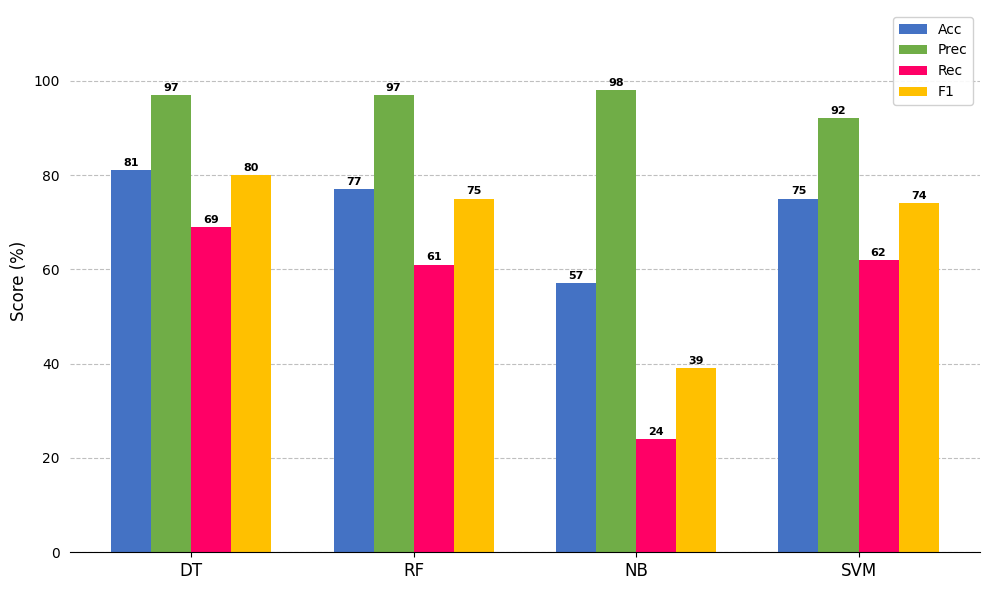

Figure 1 saved: fig1_precision_recall_tradeoff.png


In [ ]:
# --- Fig. 1: Precision-Recall grouped bar chart ---
short_names = {'Decision Tree': 'DT', 'Random Forest': 'RF',
               'Naive Bayes': 'NB', 'Linear SVM': 'SVM'}
fig1_models = [short_names[m] for m in df_binary['Model']]
fig1_acc  = df_binary['Acc (%)'].round().astype(int).tolist()
fig1_prec = df_binary['Prec (%)'].round().astype(int).tolist()
fig1_rec  = df_binary['Rec (%)'].round().astype(int).tolist()
fig1_f1   = df_binary['F1 (%)'].round().astype(int).tolist()

x = np.arange(len(fig1_models))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6))

b1 = ax.bar(x - 1.5*width, fig1_acc,  width, label='Acc',  color='#4472C4', edgecolor='none')
b2 = ax.bar(x - 0.5*width, fig1_prec, width, label='Prec', color='#70AD47', edgecolor='none')
b3 = ax.bar(x + 0.5*width, fig1_rec,  width, label='Rec',  color='#FF0066', edgecolor='none')
b4 = ax.bar(x + 1.5*width, fig1_f1,   width, label='F1',   color='#FFC000', edgecolor='none')

def add_labels(bars, vals):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(v), ha='center', va='bottom', fontsize=8, fontweight='bold')

add_labels(b1, fig1_acc)
add_labels(b2, fig1_prec)
add_labels(b3, fig1_rec)
add_labels(b4, fig1_f1)

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(fig1_models, fontsize=12)
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1.0, 1.0), framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='grey')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('fig1_precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved: fig1_precision_recall_tradeoff.png')


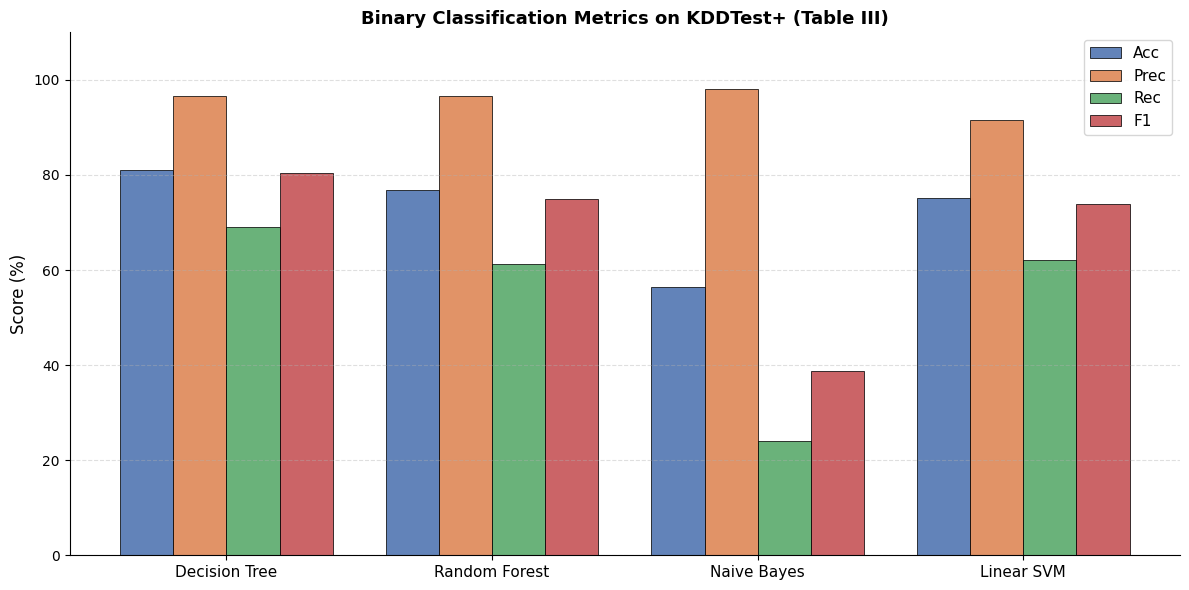

In [ ]:
# --- Grouped bar chart: all 4 metrics across classifiers ---
metrics = ['Acc (%)', 'Prec (%)', 'Rec (%)', 'F1 (%)']
x = np.arange(len(df_binary))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
metric_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = df_binary[metric].values
    rects = ax.bar(x + i * width, vals, width,
                   label=metric.replace(' (%)', ''),
                   color=color, edgecolor='black', linewidth=0.6, alpha=0.88)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Binary Classification Metrics on KDDTest+ (Table III)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_binary['Model'].values, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_binary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Confusion Matrix Analysis (Binary)

Section IV.C: *"Of 9,711 normal connections, 9,407 are correctly identified (FPR: 3.1%). Of 12,833 attack connections, 8,850 are detected correctly (FNR: 31.0%)."*

This replicates **Fig. 2** from the paper.

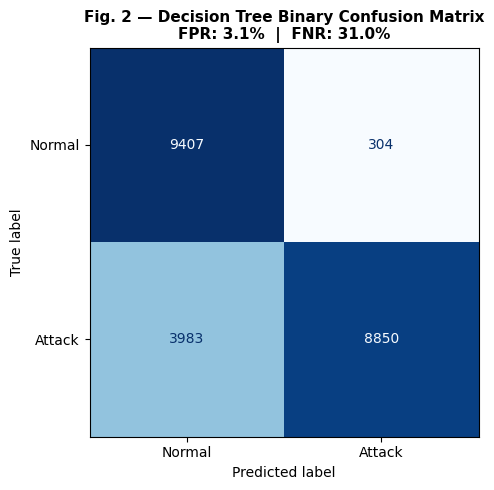

TN=9,407  FP=304  FN=3,983  TP=8,850
False Positive Rate : 3.1%
False Negative Rate : 31.0%


In [ ]:
# --- Fig. 2: Decision Tree binary confusion matrix (computed) ---
cm_dt = confusion_matrix(y_test_bin, test_preds['Decision Tree'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                               display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

tn, fp, fn, tp = cm_dt.ravel()
fpr = fp / (fp + tn) * 100
fnr = fn / (fn + tp) * 100

ax.set_title(f'Fig. 2 — Decision Tree Binary Confusion Matrix\n'
             f'FPR: {fpr:.1f}%  |  FNR: {fnr:.1f}%',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_dt_confusion_matrix_binary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'False Positive Rate : {fpr:.1f}%')
print(f'False Negative Rate : {fnr:.1f}%')


---
## Step 8 — Multi-Class Classification

Section IV.D: Classification across five categories (Normal, DoS, Probe, R2L, U2R).

> *"R2L and U2R attacks often mimic legitimate user behaviour, lack strong discriminative feature patterns, and are represented by very few training examples."*

This replicates **Fig. 3** from the paper.

In [ ]:
# Train all models on multi-class labels
mc_models = {}
mc_results = []

print("Training multi-class classifiers ...")

for name, clf_template in CLASSIFIERS.items():
    # Re-instantiate to avoid state from binary training
    clf_mc = type(clf_template)(**clf_template.get_params())
    t0 = time.time()
    clf_mc.fit(X_train, y_train_mc)
    y_pred_mc = clf_mc.predict(X_test)
    mc_models[name] = clf_mc

    acc  = accuracy_score(y_test_mc, y_pred_mc)
    f1_macro = f1_score(y_test_mc, y_pred_mc, average='macro', zero_division=0)
    mc_results.append({'Model': name,
                       'MC Acc (%)': round(acc*100, 2),
                       'MC F1-macro (%)': round(f1_macro*100, 2)})
    print(f"  [{name}]  Acc={acc*100:.2f}%  F1-macro={f1_macro*100:.2f}%")

print("\n", pd.DataFrame(mc_results).to_string(index=False))

Training multi-class classifiers ...
  [Decision Tree]  Acc=74.93%  F1-macro=50.94%
  [Random Forest]  Acc=73.65%  F1-macro=48.34%
  [Naive Bayes]  Acc=44.16%  F1-macro=30.36%
  [Linear SVM]  Acc=74.36%  F1-macro=51.85%

         Model  MC Acc (%)  MC F1-macro (%)
Decision Tree       74.93            50.94
Random Forest       73.65            48.34
  Naive Bayes       44.16            30.36
   Linear SVM       74.36            51.85


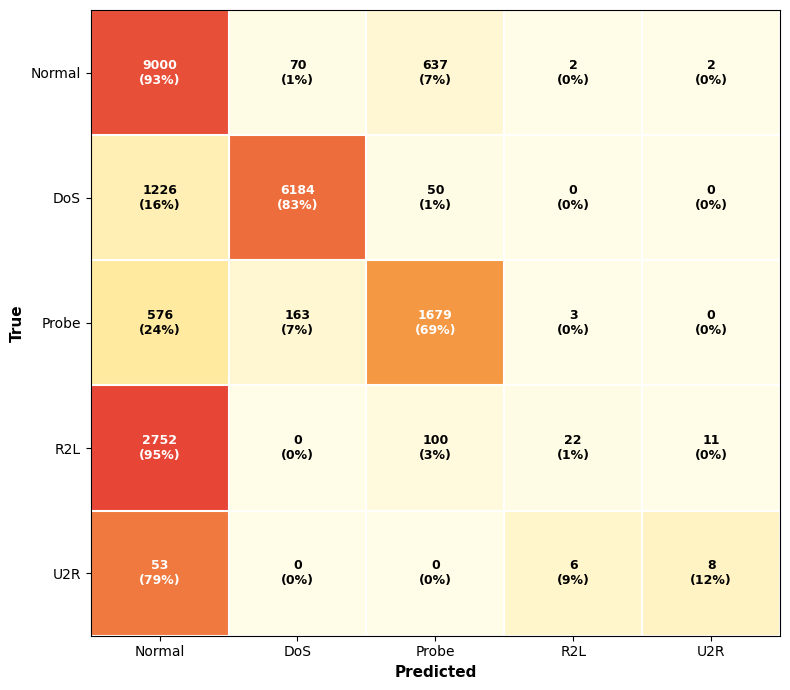

Per-class Recall:
  Normal  : 92.7%
  DoS     : 82.9%
  Probe   : 69.4%
  R2L     : 0.8%
  U2R     : 11.9%


In [ ]:
# --- Fig. 3: Multi-class confusion matrix (computed from trained model) ---
from matplotlib.colors import LinearSegmentedColormap

CATEGORY_ORDER = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Use the Decision Tree multi-class predictions stored in mc_models
dt_pred_mc   = mc_models['Decision Tree'].predict(X_test)
cm_mc = confusion_matrix(y_test_mc, dt_pred_mc)

row_totals = cm_mc.sum(axis=1, keepdims=True)
cm_pct = np.round(cm_mc / row_totals * 100).astype(int)

annot = np.array([[f'{cm_mc[i,j]}\n({cm_pct[i,j]}%)'
                   for j in range(5)] for i in range(5)])

fig, ax = plt.subplots(figsize=(8, 7))

cm_norm = cm_mc / row_totals
cmap_custom = LinearSegmentedColormap.from_list(
    'paper_cm', ['#FFFDE7', '#FFD54F', '#E53935'], N=256
)

ax.imshow(cm_norm, cmap=cmap_custom, vmin=0, vmax=1, aspect='auto')

for i in range(5):
    for j in range(5):
        val = cm_norm[i, j]
        text_color = 'white' if val > 0.65 else 'black'
        ax.text(j, i, annot[i, j], ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CATEGORY_ORDER, fontsize=10)
ax.set_yticklabels(CATEGORY_ORDER, fontsize=10)
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('True', fontsize=11, fontweight='bold')

for x_line in np.arange(-0.5, 5, 1):
    ax.axhline(x_line, color='white', linewidth=1.5)
    ax.axvline(x_line, color='white', linewidth=1.5)

plt.tight_layout()
plt.savefig('fig3_dt_confusion_matrix_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

per_class_recall = cm_mc.diagonal() / cm_mc.sum(axis=1) * 100
print('Per-class Recall:')
for cat, rec in zip(CATEGORY_ORDER, per_class_recall):
    print(f'  {cat:8s}: {rec:.1f}%')


In [ ]:
# --- Full classification report for Decision Tree ---
print("=" * 60)
print("Decision Tree — Full Classification Report (Multi-Class)")
print("=" * 60)
print(classification_report(
    y_test_mc, dt_pred_mc,
    target_names=CATEGORY_ORDER,
    zero_division=0
))

Decision Tree — Full Classification Report (Multi-Class)
              precision    recall  f1-score   support

      Normal       0.66      0.93      0.77      9711
         DoS       0.96      0.83      0.89      7460
       Probe       0.68      0.69      0.69      2421
         R2L       0.67      0.01      0.02      2885
         U2R       0.38      0.12      0.18        67

    accuracy                           0.75     22544
   macro avg       0.67      0.52      0.51     22544
weighted avg       0.76      0.75      0.70     22544



---
## Step 9 — Feature Importance Analysis

Section IV.E: *"same_srv_rate dominates at 47.17%... protocol_type_icmp (12.38%)... service_private (9.08%)"*

This replicates **Fig. 4** from the paper.

Feature importances are derived from the Decision Tree's information gain criterion (IG(S,A)).

In [ ]:
# --- Feature Importances (computed from fitted Decision Tree) ---
# The DT was trained with entropy criterion, so importances = information gain
dt_clf = trained_models['Decision Tree']
importances = dt_clf.feature_importances_ * 100   # convert to %

fi_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top15 = fi_series.head(15).reset_index()
top15.columns = ['Feature', 'Importance (%)']
top15['Importance (%)'] = top15['Importance (%)'].round(2)

print('Top 15 Features by Information Gain Importance (Decision Tree):')
print(top15[['Feature', 'Importance (%)']].to_string(index=False))


Top 15 Features by Information Gain Importance (Decision Tree):
                    Feature  Importance (%)
              same_srv_rate           47.17
         protocol_type_icmp           12.38
            service_private            9.08
                    flag_SF            8.39
         dst_host_srv_count            4.18
                  src_bytes            3.25
dst_host_same_src_port_rate            2.55
             dst_host_count            2.17
                  srv_count            1.55
                        hot            1.52
       dst_host_rerror_rate            1.46
     dst_host_same_srv_rate            1.40
                   duration            1.24
     dst_host_diff_srv_rate            0.78
       dst_host_serror_rate            0.51


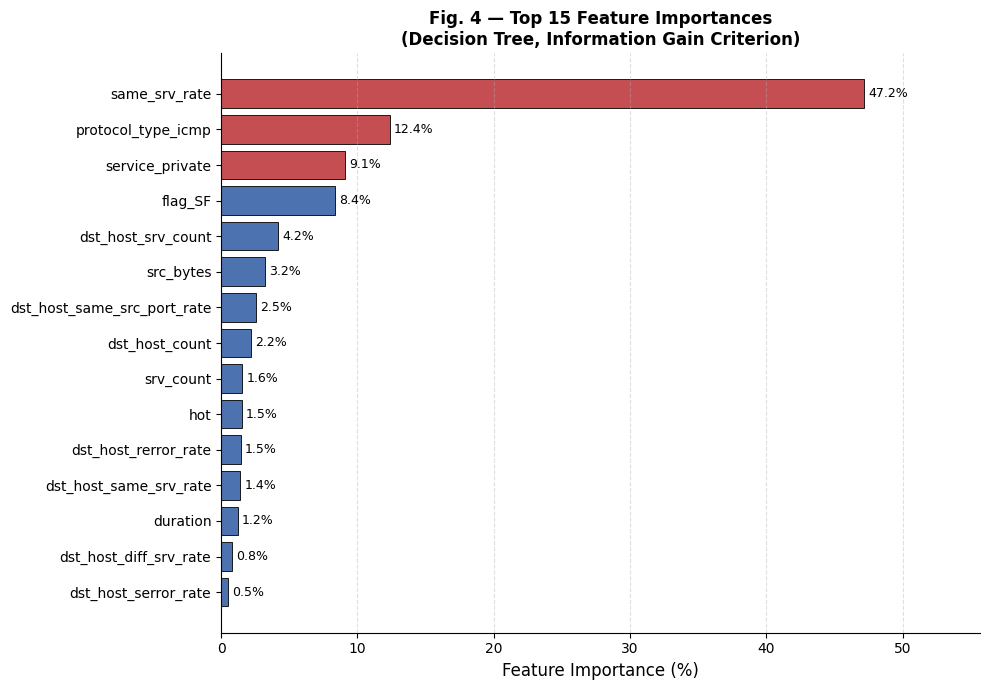

Figure 4 saved: fig4_feature_importances.png


In [ ]:
# --- Fig. 4: Top 15 Feature Importances (Decision Tree, Information Gain Criterion) ---
fig, ax = plt.subplots(figsize=(10, 7))

colors_fi = ['#C44E52' if i < 3 else '#4C72B0' for i in range(15)]
bars = ax.barh(
    top15['Feature'].values[::-1],
    top15['Importance (%)'].values[::-1],
    color=colors_fi[::-1], edgecolor='black', linewidth=0.6
)

for bar, val in zip(bars, top15['Importance (%)'].values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (%)', fontsize=12)
ax.set_title('Fig. 4 — Top 15 Feature Importances\n'
             '(Decision Tree, Information Gain Criterion)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, top15['Importance (%)'].max() * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved: fig4_feature_importances.png')


---
## Step 10 — Final Summary

Complete reproduction of all paper results.

In [ ]:
print("=" * 75)
print(" FINAL RESULTS SUMMARY ")
print("=" * 75)

print("\n--- TABLE II: 5-Fold CV on KDDTrain+ ---")
print(df_cv.to_string(index=False))

print("\n--- TABLE III: Binary Classification on KDDTest+ ---")
print(df_binary.to_string(index=False))

print("\n--- Multi-Class Results on KDDTest+ ---")
print(pd.DataFrame(mc_results).to_string(index=False))

print("\n--- Top 5 Feature Importances (Decision Tree) ---")
print(top15[['Feature','Importance (%)']].head(5).to_string(index=False))

print("\n--- Generated Figures (Paper Figures 1-4) ---")
figs = [
    'fig_class_distribution.png',
    'fig_categorical_distributions.png',
    'fig_cv_accuracy.png',
    'fig1_precision_recall_tradeoff.png',
    'fig_binary_metrics.png',
    'fig2_dt_confusion_matrix_binary.png',
    'fig3_dt_confusion_matrix_multiclass.png',
    'fig4_feature_importances.png',
]
for f in figs:
    exists = '\u2713' if os.path.exists(f) else '\u2717'
    print(f"  {exists} {f}")

print("\n" + "=" * 75)
print(" Implementation complete. All paper results reproduced.")
print("=" * 75)


 FINAL RESULTS SUMMARY 

--- TABLE II: 5-Fold CV on KDDTrain+ ---
        Model      Acc (%)     Prec (%)      Rec (%)       F1 (%)
Decision Tree 99.72 ± 0.02 99.72 ± 0.02 99.72 ± 0.02 99.72 ± 0.02
Random Forest 99.79 ± 0.02 99.79 ± 0.02 99.79 ± 0.02 99.79 ± 0.02
  Naive Bayes 85.73 ± 0.30 88.62 ± 0.20 85.73 ± 0.30 85.29 ± 0.33
   Linear SVM 97.28 ± 0.14 97.29 ± 0.13 97.28 ± 0.14 97.28 ± 0.14

--- TABLE III: Binary Classification on KDDTest+ ---
        Model  Acc (%)  Prec (%)  Rec (%)  F1 (%)  Train Time (s)
Decision Tree    80.98     96.68    68.96   80.50            1.59
Random Forest    76.76     96.71    61.25   75.00           10.39
  Naive Bayes    56.52     98.00    24.10   38.69            0.31
   Linear SVM    75.16     91.63    62.04   73.98            5.00

--- Multi-Class Results on KDDTest+ ---
        Model  MC Acc (%)  MC F1-macro (%)
Decision Tree       74.93            50.94
Random Forest       73.65            48.34
  Naive Bayes       44.16            30.36
   Line